In [19]:
import numpy as np
import pandas as pd
import scanpy as sc
import stckit as stk

In [16]:
# Load data
np.random.seed(42)
adata = sc.read_h5ad('../data/Y10009L7_raw.h5ad')

# Filter low-quality cells (20-100 ADTs detected)
stk.pp.filter_cells(adata, min_adt_proteins=20, max_adt_proteins=100)

# Leiden clustering on CLR-normalized ADT data
stk.pp.cluster_cells(adata, data_type='cite', resolution=0.4, pseudocount=1.0)

/Data/user/zhuqianhua/01.bins/miniconda3/envs/dev/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
/Data/user/zhuqianhua/01.bins/miniconda3/envs/dev/lib/python3.9/site-packages/anndata/_core/aligned_df.py:68: ImplicitModificationWarning: Transforming to str index.
  warnings.warn("Transforming to str index.", ImplicitModificationWarning)
2026-04-14 16:42:05,185 - INFO - Using provided AnnData object
2026-04-14 16:42:05,186 - INFO - Data shape: 145597 cells x 168 features
2026-04-14 16:42:05,186 - INFO - Checking and backing up raw counts...
2026-04-14 16:42:05,297 - INFO -   Backing up raw counts to layers['counts']


[QC] Preserving 7928 cells matching prefix(es): ['dapi']
[QC] ADT mode: matrix shape (184880, 168)
[QC] ADT proteins range: 0 - 167
[QC]   min_adt_proteins >= 20 (preserved cells excluded)
[QC]   max_adt_proteins <= 100 (preserved cells excluded)
[QC] ADT filtering: keeping 145597/184880 cells (39283 removed, 7928 preserved)
[QC] Filtered: 184880 -> 145597 cells, 168 -> 168 genes


2026-04-14 16:42:05,375 - INFO - Rare cells: 7928, Main cells: 137669
2026-04-14 16:42:05,375 - INFO - Applying CITE normalization to main cells...
2026-04-14 16:42:05,378 - INFO - CLR normalization: pseudocount=1.0, depth_correct=True
2026-04-14 16:42:05,426 - INFO -   Skipping depth correction: median depth 664 is within acceptable range (target: 1000)
2026-04-14 16:42:05,597 - INFO - CLR normalization complete
2026-04-14 16:42:05,598 - INFO - Successfully applied cite normalization
2026-04-14 16:42:05,599 - INFO - Processing 7928 rare cells...
2026-04-14 16:42:05,600 - INFO - CLR normalization: pseudocount=1.0, depth_correct=True
2026-04-14 16:42:05,602 - INFO -   Skipping depth correction: median depth 231 is within acceptable range (target: 1000)
2026-04-14 16:42:05,606 - INFO - CLR normalization complete
2026-04-14 16:42:05,607 - INFO - Successfully applied cite normalization


computing PCA
    with n_comps=50
    finished (0:00:01)


2026-04-14 16:42:07,297 - INFO - Variance explained by 50 PCs: 75.62%


computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:08)
computing UMAP
    finished: added
    'X_umap', UMAP coordinates (adata.obsm)
    'umap', UMAP parameters (adata.uns) (0:00:40)
running Leiden clustering
    finished: found 18 clusters and added
    'leiden', the cluster labels (adata.obs, categorical) (0:00:02)


2026-04-14 16:42:58,552 - INFO - Cells clustered into 18 clusters
2026-04-14 16:42:58,582 - INFO - Rare cells labeled as 'rare' (no sub-clustering)
2026-04-14 16:42:58,582 - INFO - Fitting UMAP on main cells and projecting rare cells...
/Data/user/zhuqianhua/01.bins/miniconda3/envs/dev/lib/python3.9/site-packages/umap/umap_.py:1952: UserWarning: n_jobs value 1 overridden to 1 by setting random_state. Use no seed for parallelism.
  warn(


computing neighbors
    using 'X_pca' with n_pcs = 50
    finished: added to `.uns['neighbors']`
    `.obsp['distances']`, distances for each pair of neighbors
    `.obsp['connectivities']`, weighted adjacency matrix (0:00:08)


2026-04-14 16:43:59,502 - INFO - Final dataset: 145597 cells
2026-04-14 16:43:59,504 - INFO - Total clusters: 19
2026-04-14 16:43:59,505 - INFO -   - Main cell clusters: 18
2026-04-14 16:43:59,505 - INFO -   - Rare cells: 7928 (labeled as 'rare')


... storing 'leiden' as categorical


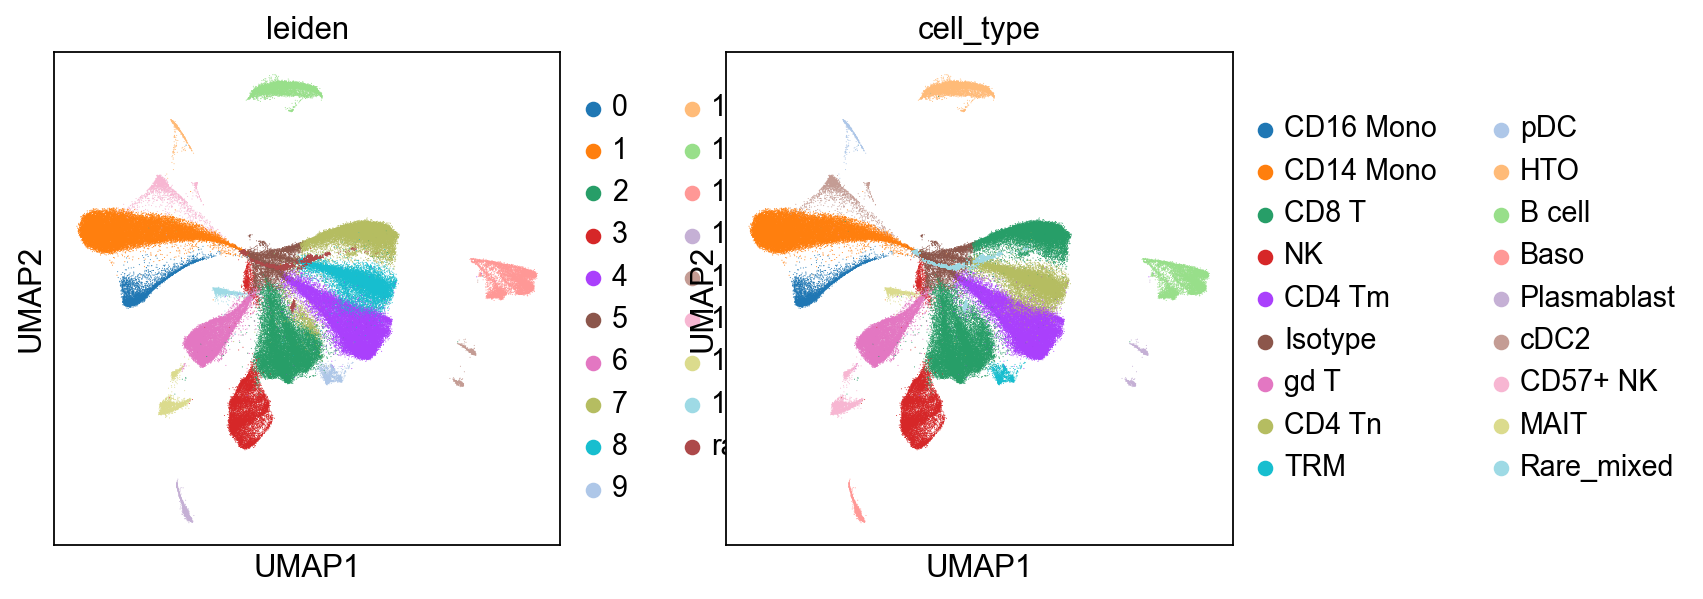

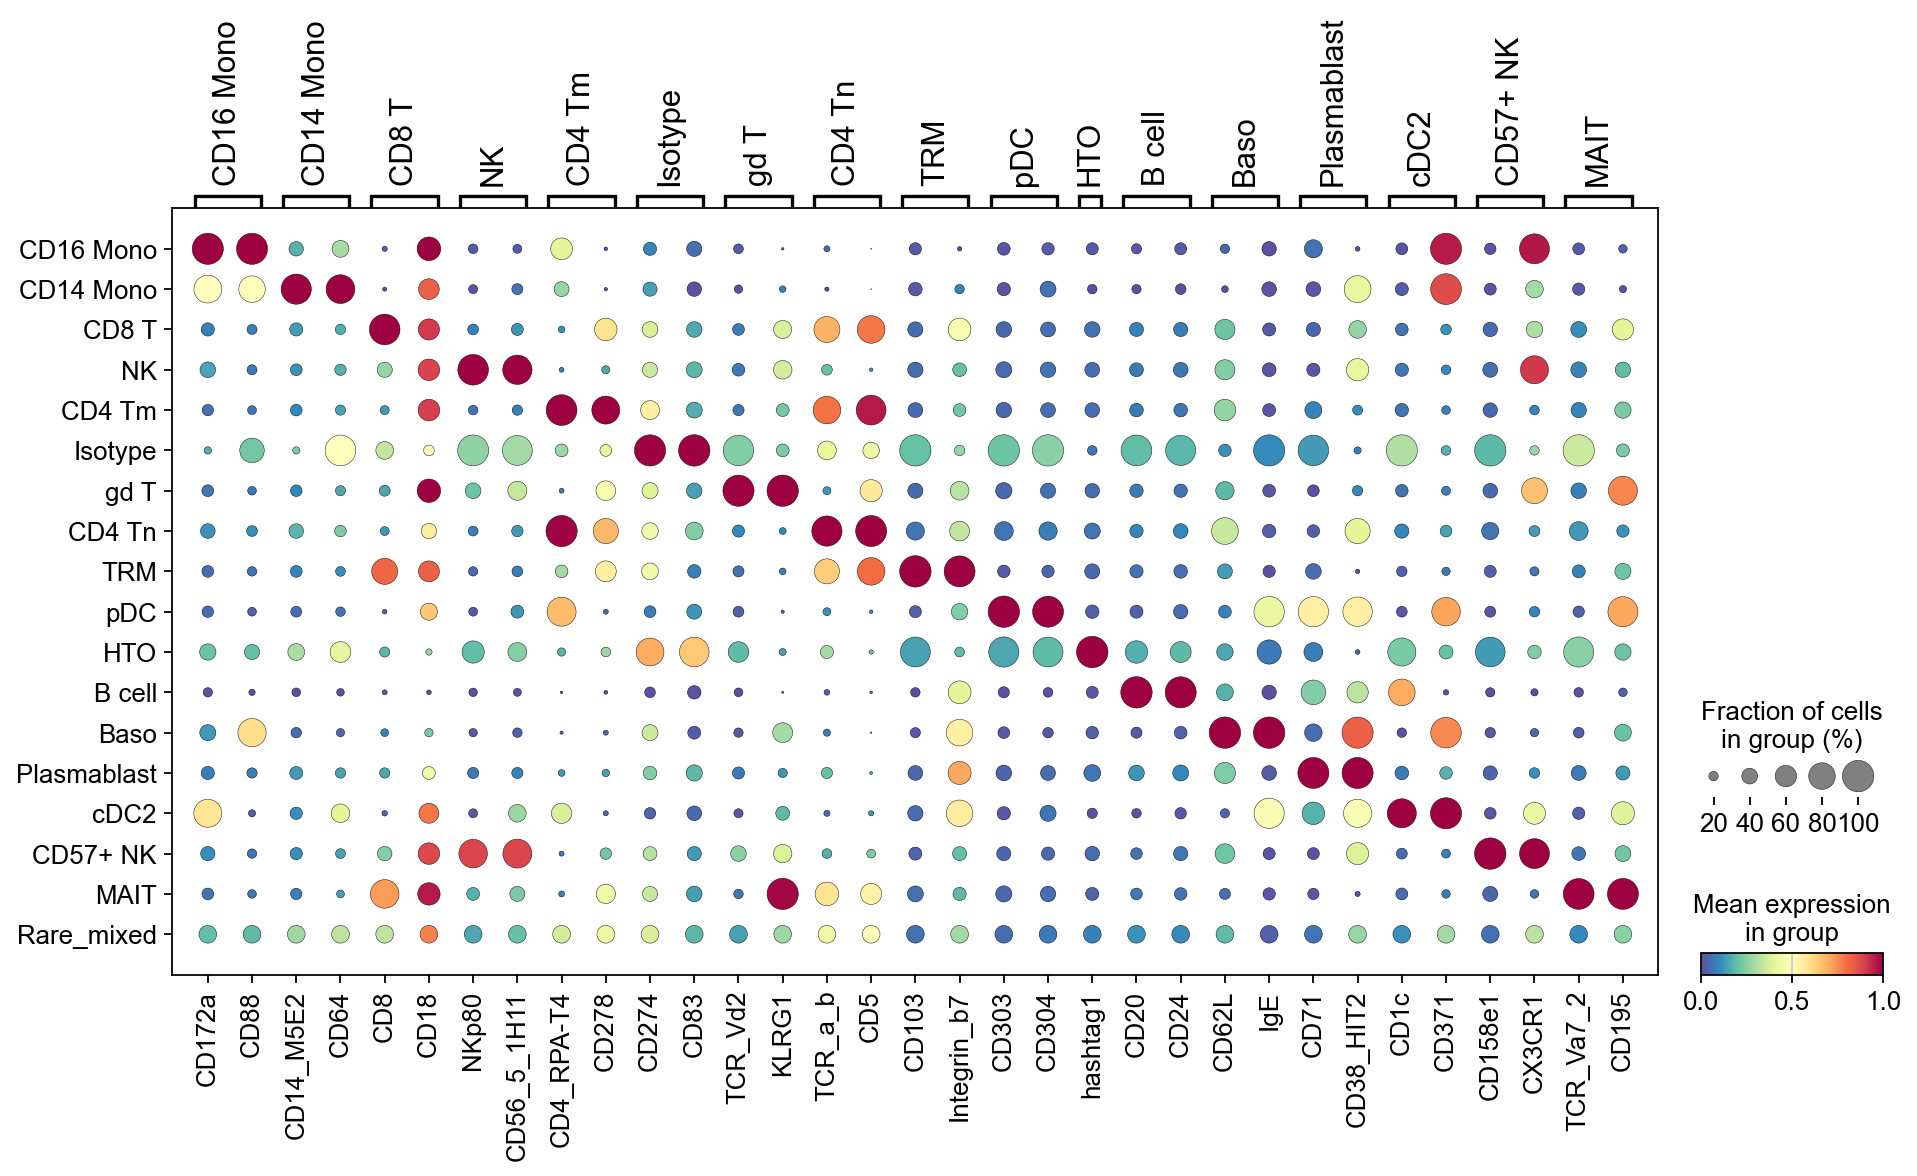

In [20]:
cell_type_markers = {
    "CD16 Mono": ["CD172a", "CD88"],           # CD16+ monocytes / mDCs
    "CD14 Mono": ["CD14_M5E2", "CD64"],        # Classical monocytes
    "CD8 T": ["CD8", "CD18"],                  # CD8+ T cells (effector + naive)
    "NK": ["NKp80", "CD56_5_1H11"],            # Natural killer cells
    "CD4 Tm": ["CD4_RPA-T4", "CD278"],         # CD4+ memory T cells
    "Isotype": ["CD274", "CD83"],              # Isotype control / background
    "gd T": ["TCR_Vd2", "KLRG1"],              # Gamma-delta T cells
    "CD4 Tn": ["TCR_a_b", "CD5"],              # CD4+ naive T cells
    "TRM": ["CD103", "Integrin_b7"],           # Tissue-resident memory T cells
    "pDC": ["CD303", "CD304"],                 # Plasmacytoid dendritic cells
    "HTO": ["hashtag1"],                       # Hashtag oligonucleotides (multiplexing)
    "B cell": ["CD20", "CD24"],                # B lymphocytes
    "Baso": ["CD62L", "IgE"],                  # Basophils
    "Plasmablast": ["CD71", "CD38_HIT2"],      # Activated B cells / plasmablasts
    "cDC2": ["CD1c", "CD371"],                 # Conventional dendritic cells type 2
    "CD57+ NK": ["CD158e1", "CX3CR1"],         # Mature / CD57+ NK cells
    "MAIT": ["TCR_Va7_2", "CD195"]             # Mucosal-associated invariant T cells
}

cluster_annotation = {
    '0': "CD16 Mono", '1': "CD14 Mono", '2': "CD8 T", '3': "NK",
    '4': "CD4 Tm", '5': "Isotype", '6': "gd T", '7': "CD8 T",      # Cluster 7 merged to CD8 T
    '8': "CD4 Tn", '9': "TRM", '10': "pDC", '11': "HTO",
    '12': "B cell", '13': "Baso", '14': "Plasmablast", '15': "cDC2",
    '16': "CD57+ NK", '17': "MAIT"
}

# Assign label to rare cells
cluster_annotation['rare'] = "Rare_mixed"
cell_type_markers["Rare_mixed"] = ['mixed_pbmc']

# Map cluster IDs to cell type annotations
adata.obs['leiden'] = adata.obs['leiden'].astype(str)
adata.obs['cell_type'] = adata.obs['leiden'].map(cluster_annotation)

# Set categorical order to match marker dictionary
adata.obs['cell_type'] = pd.Categorical(
    adata.obs['cell_type'], categories=list(cell_type_markers.keys())
)

# Exclude non-biological categories from marker visualization
plot_markers = {k: v for k, v in cell_type_markers.items() 
                if k not in ["Unknown", "Rare_mixed", "Doublets", "rare"]}

# Visualize clustering and annotations
sc.pl.umap(adata, color=['leiden', 'cell_type'])
sc.pl.dotplot(adata, plot_markers, groupby='cell_type', 
              standard_scale='var', cmap='Spectral_r')

# Store markers and save annotated data
adata.uns['cell_type_markers'] = plot_markers
adata.write_h5ad('../data/Y10009L7_annotated.h5ad')